In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project='realBathy'
ed='run1/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

if project=='realBathy':
    for i in np.arange(10,50,10):
        var='dynDiag'+str(i)
        if i==10:
            ds=xr.open_dataset(str(location) +  str(var) + '.nc')
        else:
            ds=ds.merge(xr.open_dataset(str(location) +  str(var) + '.nc'))
else:
    var='dynDiag'
    ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag40'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid40'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
if project=='realBathy':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [3]:
start=np.where(ds.T/(60*60*24*360)>=1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=3)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [4]:
len(dsG.Depth[:,0]) -int(ny/4)

378

In [5]:
umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
umbral2=np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==np.min(dsG.Depth[int(ny/2):-int(ny/4),20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==600)[0])/2)]+int(ny/2)+1
umbral3=np.where(dsG.Depth[-int(ny/4):,20].values==np.min(dsG.Depth[-int(ny/4):,20].values))[0][-1]+(len(dsG.Depth[:,0])-int(ny/4))-7


umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]==np.max(dsG.Depth[:int(ny/2),20]))[0][0]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [128]:
depindUmb=np.where(dsG.Z>=-600)[0][-2]
depind800=np.where(dsG.Z<-800)[0][0]-1
umbralStart2=np.where(dsG.Depth[umbralEnd1:,20]<np.max(dsG.Depth))[0][0]+umbralEnd1


In [130]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 3),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

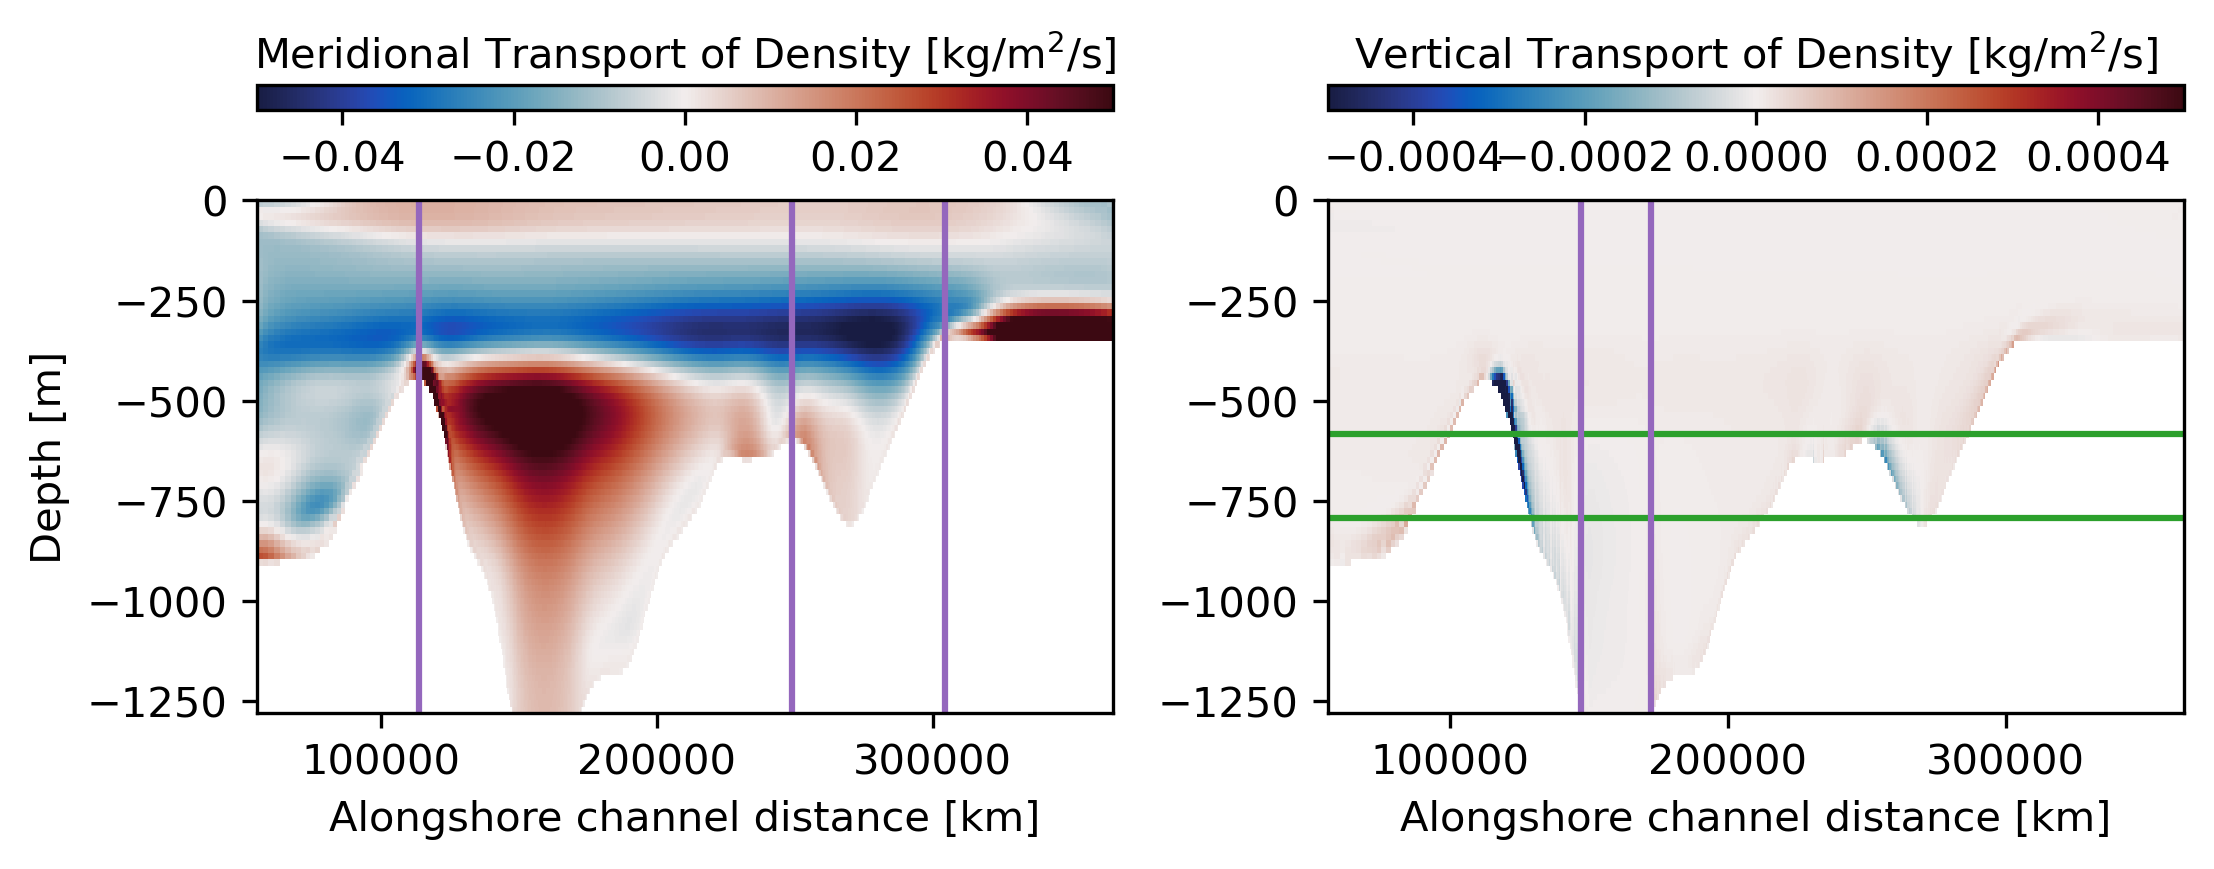

In [131]:
fig,axin=plt.subplots(1,2)
ax=axin[0]
title='Meridional Transport of Density [kg/m$^2$/s]'
cax= ax.pcolormesh(dsG.Yp1[OB:OBend],dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,OB:OBend,OB:OBendx],axis=0),mask=masks[:,OB:OBend,OB:OBendx]),axis=2),vmin=-0.05,vmax=0.05,cmap=cmocean.cm.balance)
ax.axvline(dsG.Yp1[umbral1],color='tab:purple')
ax.axvline(dsG.Yp1[umbral2],color='tab:purple')
ax.axvline(dsG.Yp1[umbral3],color='tab:purple')

divider = make_axes_locatable(ax)
axdiv = divider.new_vertical(size = '5%', pad = 0.3)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)
ax.set(xlabel='Alongshore channel distance [km]',ylabel='Depth [m]')

ax=axin[1]
title='Vertical Transport of Density [kg/m$^2$/s]'
cax= ax.pcolormesh(dsG.Y[OB:OBend],dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.WRHOMASS[:,:,OB:OBend,OB:OBendx],axis=0),mask=mask[:,OB:OBend,OB:OBendx]),axis=2),vmin=-0.0005,vmax=0.0005,cmap=cmocean.cm.balance)
ax.axhline(dsG.Z[depindUmb],color='tab:green')
ax.axhline(dsG.Z[depind800],color='tab:green')

ax.axvline(dsG.Y[umbralEnd1],color='tab:purple')
ax.axvline(dsG.Y[umbralStart2],color='tab:purple')

divider = make_axes_locatable(ax)
axdiv = divider.new_vertical(size = '5%', pad = 0.3)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)
ax.set(xlabel='Alongshore channel distance [km]')
fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'AlongChannelTransport.png', bbox_inches='tight')

## Vertical transport

In [101]:
Area=dsG.rA[umbralEnd1:,OBx:OBendx].values*dsG.HFacC[depindUmb,umbralEnd1:,OBx:OBendx].values
transpDens1=np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[:,depindUmb,umbralEnd1:,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:,OBx:OBendx]))
transpSv1=np.sum(Area*np.ma.masked_array(np.mean(ds.WVEL[:,depindUmb,umbralEnd1:,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:,OBx:OBendx]))*1e-6

print(f'Total upwelling transport after first sill at depth 600 m {transpDens1:.3f} kg/m^2/s or {transpSv1:.3f} Sv')



Total upwelling transport after first sill at depth 600 m 0.081 kg/m^2/s or 0.009 Sv


In [132]:
Area=dsG.rA[umbralEnd1:umbralStart2,OBx:OBendx].values*dsG.HFacC[depindUmb,umbralEnd1:umbralStart2,OBx:OBendx].values
transpSv2=np.sum(Area*np.ma.masked_array(np.mean(ds.WVEL[-5:,depindUmb,umbralEnd1:umbralStart2,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart2,OBx:OBendx]))*1e-6
transpDens2=np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[-5:,depindUmb,umbralEnd1:umbralStart2,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart2,OBx:OBendx]))
print(f'Total upwelling transport between topography at depth 600 m {transpDens2:.3f} kg/m^2/s or {transpSv2:.3f} Sv')



Total upwelling transport between topography at depth 600 m 0.024 kg/m^2/s or 0.003 Sv


In [137]:
Area=dsG.rA[umbralEnd1:,OBx:OBendx].values*dsG.HFacC[depind800,umbralEnd1:,OBx:OBendx].values
transpDens3=np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800,umbralEnd1:,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:,OBx:OBendx]))
transpSv3=np.sum(Area*np.ma.masked_array(np.mean(ds.WVEL[:,depind800,umbralEnd1:,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:,OBx:OBendx]))*1e-6

print(f'Total upwelling transport after first sill at depth 800 m {transpDens3:.3f} kg/m^2/s or {transpSv3:.3f} Sv')



Total upwelling transport after first sill at depth 800 m 0.014 kg/m^2/s or 0.001 Sv


In [136]:
Area=dsG.rA[umbralEnd1:umbralStart2,OBx:OBendx].values*dsG.HFacC[depind800,umbralEnd1:umbralStart2,OBx:OBendx].values
transpSv4=np.sum(Area*np.ma.masked_array(np.mean(ds.WVEL[-5:,depind800,umbralEnd1:umbralStart2,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:umbralStart2,OBx:OBendx]))*1e-6
transpDens4=np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[-5:,depind800,umbralEnd1:umbralStart2,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:umbralStart2,OBx:OBendx]))
print(f'Total upwelling transport between topography at depth 800 m {transpDens4:.3f} kg/m^2/s or {transpSv4:.3f} Sv')



Total upwelling transport between topography at depth 800 m 0.020 kg/m^2/s or 0.002 Sv


In [159]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 6),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

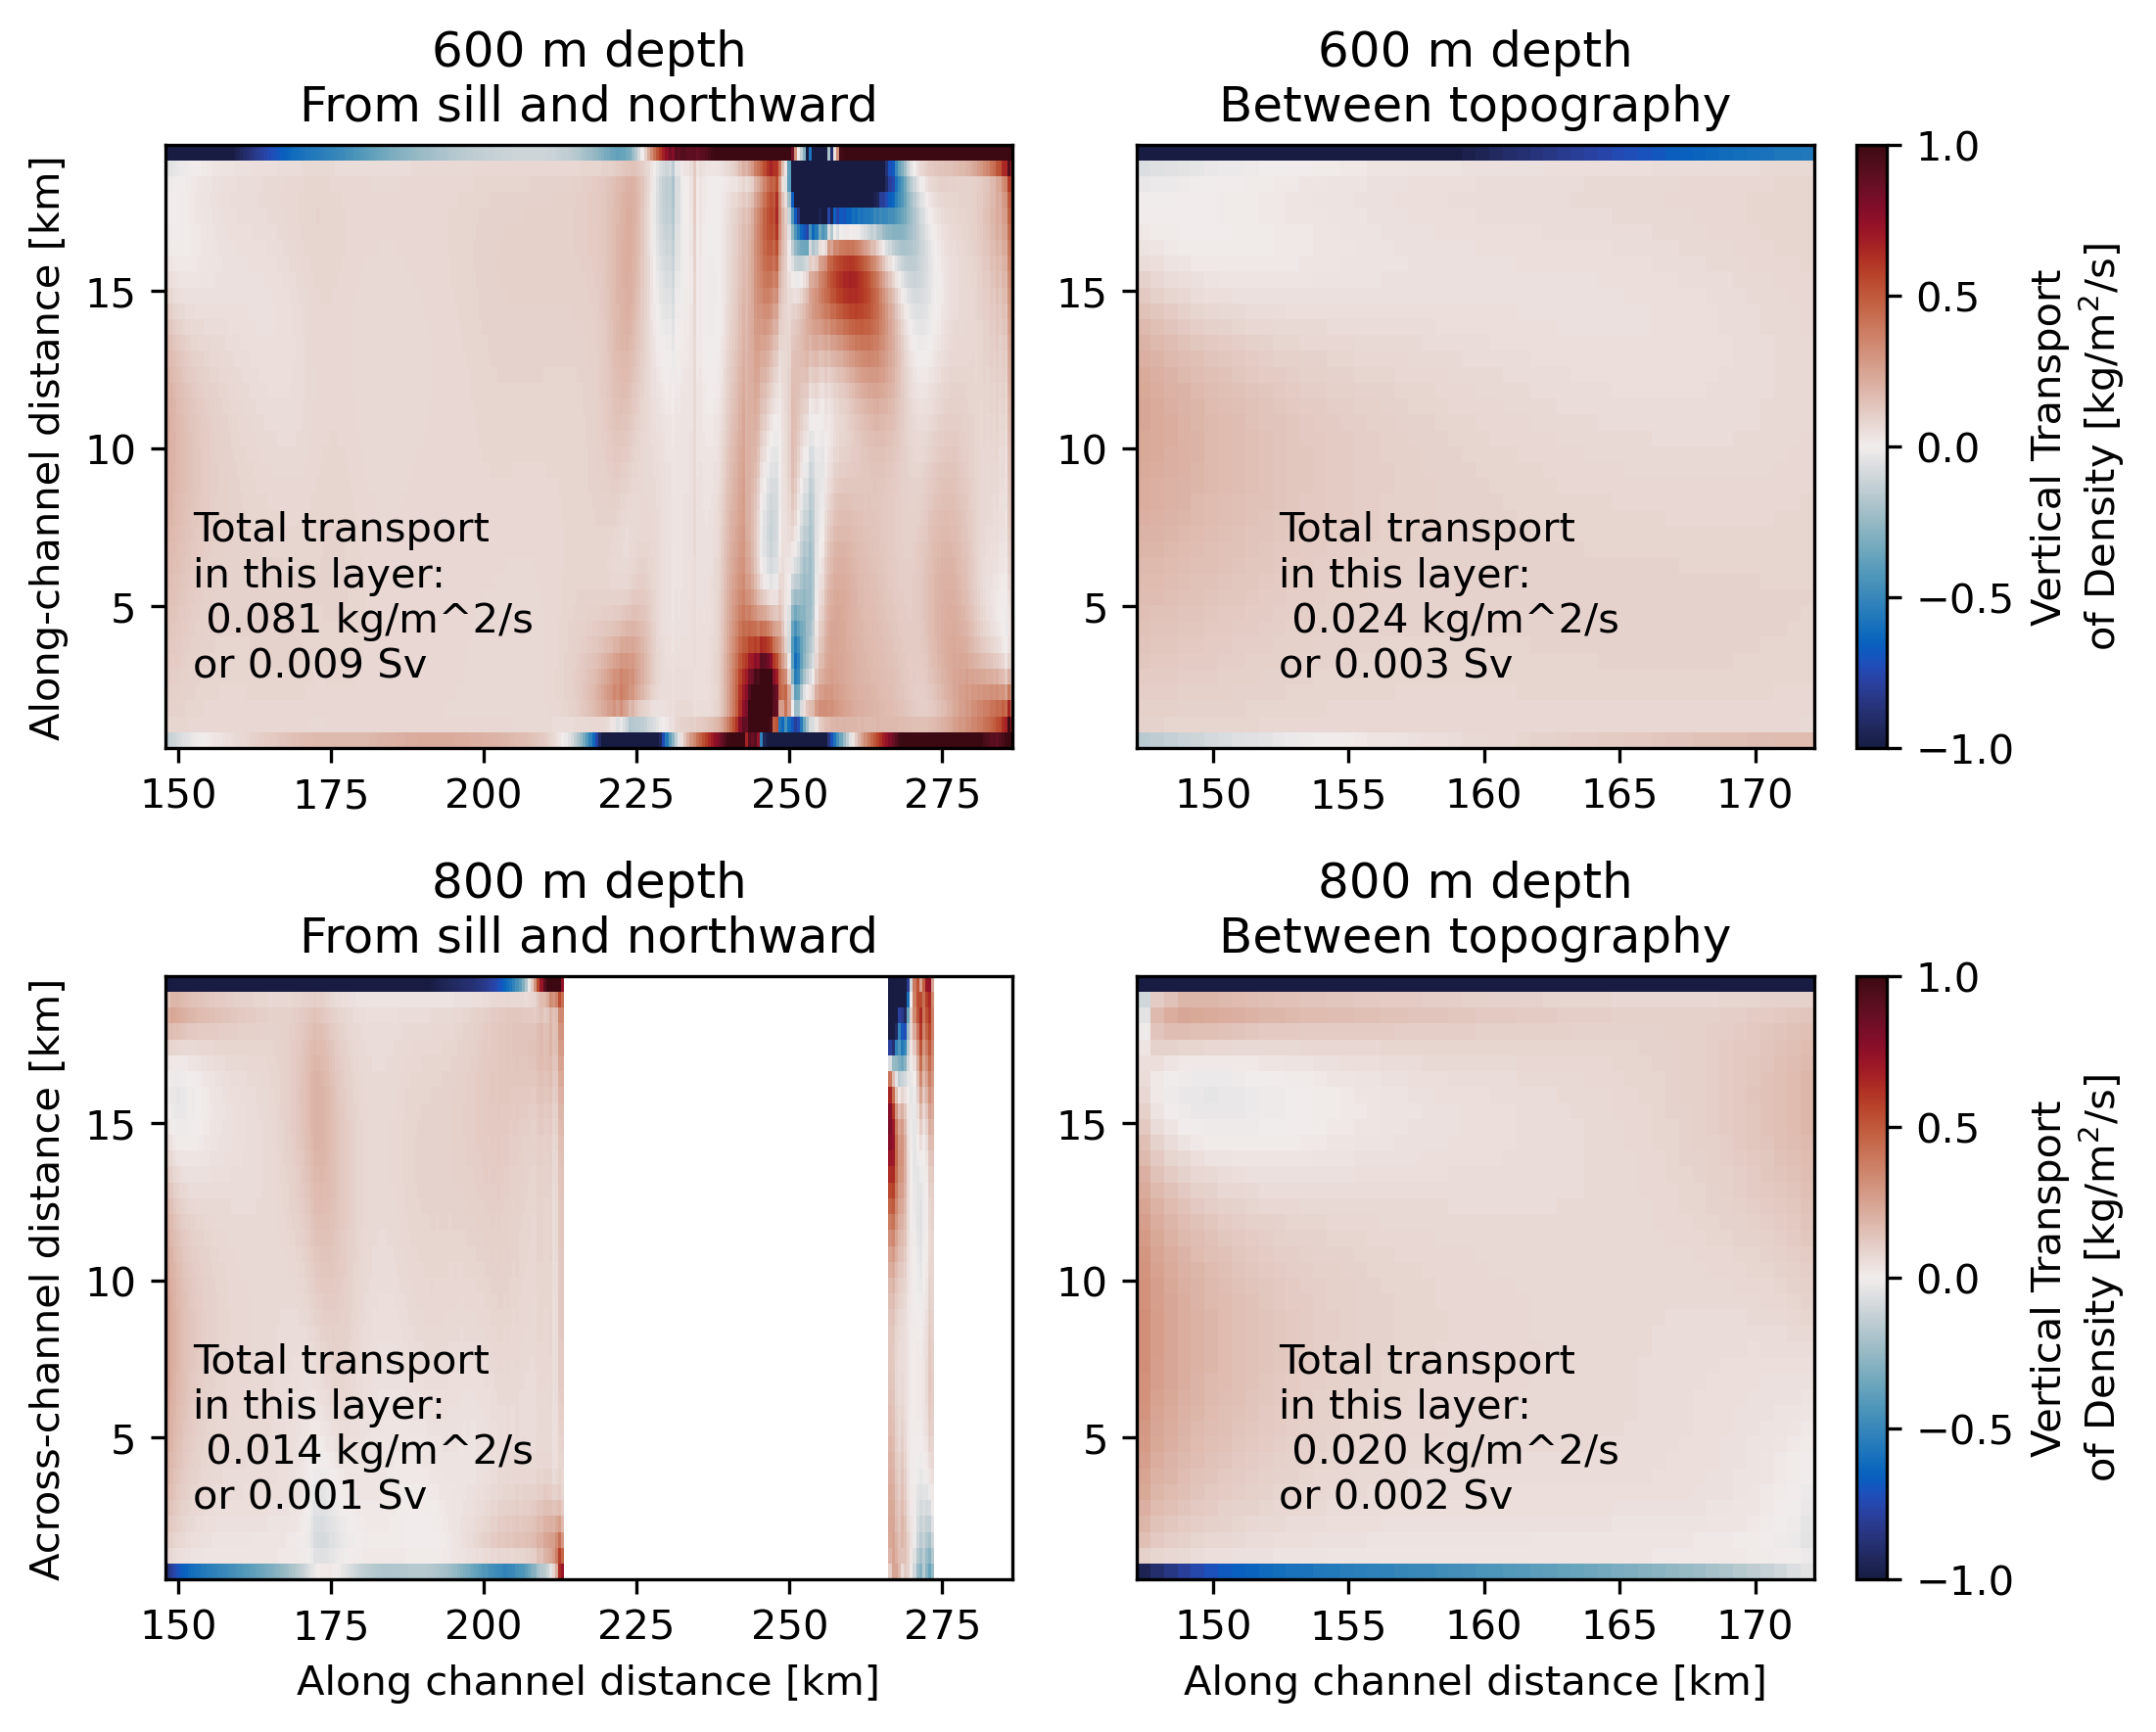

In [165]:
indy=np.arange(umbral1,umbralEnd1,1)
p=0 #np.arange(0,50,10)[0]
start=-5
fig,axin=plt.subplots(2,2)
ax=axin[0,0]
cax=ax.pcolormesh(dsG.Y[umbralEnd1:]/1000,dsG.X[OBx:OBendx]/1000,np.ma.masked_array(np.mean(ds.WRHOMASS[:,depindUmb,umbralEnd1:,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:,OBx:OBendx]).T*1e4,vmin=-1,vmax=1,cmap=cmocean.cm.balance)
ax.set(ylabel='Along-channel distance [km]',title='600 m depth\nFrom sill and northward')

ax.text(dsG.Y[umbralEnd1+10]/1000,dsG.X[5]/1000,  f'Total transport\nin this layer:\n {transpDens1:.3f} kg/m^2/s\nor {transpSv1:.3f} Sv', color='k',fontsize=10)

ymax=dsG.Y[umbralEnd1:].values[mask[depindUmb,umbralEnd1:,5]==False][-1]
ymin=dsG.Y[umbralEnd1:].values[mask[depindUmb,umbralEnd1:,5]==False][1]
ax.set_xlim((ymin/1000,ymax/1000))

ax=axin[0,1]
cax=ax.pcolormesh(dsG.Y[umbralEnd1:umbralStart2]/1000,dsG.X[OBx:OBendx]/1000,np.ma.masked_array(np.mean(ds.WRHOMASS[:,depindUmb,umbralEnd1:umbralStart2,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart2,OBx:OBendx]).T*1e4,vmin=-1,vmax=1,cmap=cmocean.cm.balance)
cbar=plt.colorbar(cax)
cbar.set_label('Vertical Transport\nof Density [kg/m$^2$/s]')

ax.set(title='600 m depth\nBetween topography')

ax.text(dsG.Y[umbralEnd1+10]/1000, dsG.X[5]/1000, f'Total transport\nin this layer:\n {transpDens2:.3f} kg/m^2/s\nor {transpSv2:.3f} Sv', color='k',fontsize=10)


ax=axin[1,0]
cax=ax.pcolormesh(dsG.Y[umbralEnd1:]/1000,dsG.X[OBx:OBendx]/1000,np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800,umbralEnd1:,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:,OBx:OBendx]).T*1e4,vmin=-1,vmax=1,cmap=cmocean.cm.balance)
ax.set(xlabel='Along channel distance [km]',ylabel='Across-channel distance [km]',title='800 m depth\nFrom sill and northward')

ax.text( dsG.Y[umbralEnd1+10]/1000, dsG.X[5]/1000,f'Total transport\nin this layer:\n {transpDens3:.3f} kg/m^2/s\nor {transpSv3:.3f} Sv', color='k',fontsize=10)

ax.set_xlim((ymin/1000,ymax/1000))

ax=axin[1,1]
cax=ax.pcolormesh(dsG.Y[umbralEnd1:umbralStart2]/1000,dsG.X[OBx:OBendx]/1000,np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800,umbralEnd1:umbralStart2,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:umbralStart2,OBx:OBendx]).T*1e4,vmin=-1,vmax=1,cmap=cmocean.cm.balance)
cbar=plt.colorbar(cax)
cbar.set_label('Vertical Transport\nof Density [kg/m$^2$/s]')

ax.set(xlabel='Along channel distance [km]',title='800 m depth\nBetween topography')

ax.text(dsG.Y[umbralEnd1+10]/1000,dsG.X[5]/1000, f'Total transport\nin this layer:\n {transpDens4:.3f} kg/m^2/s\nor {transpSv4:.3f} Sv', color='k',fontsize=10)

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'VertTransport.png', bbox_inches='tight')

## Meridional transport

In [46]:
Area=(dsG.dxG.values[umbral1,OB:OBendx]*dsG.HFacS[:,umbral1,OB:OBendx].values)*dsG.drF.values[:,None]
transpDens=np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral1,OB:OBendx],axis=0),mask=masks[:,umbral1,OB:OBendx]))
transpSv=np.sum(Area*np.ma.masked_array(np.mean(ds.VVEL[:,:,umbral1,OB:OBendx],axis=0),mask=masks[:,umbral1,OB:OBendx]))*1e-6
f'Total transport on first sill {transpDens:.1f} kg/m^2/s or {transpSv:.4f} Sv'



'Total transport on first sill -2.1 kg/m^2/s or -0.0101 Sv'

In [22]:
f'Total transport on second sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral2,OBx:OBendx],axis=0),mask=masks[:,umbral2,OBx:OBendx])):.1f} kg/m^2/s'



'Total transport on second sill 0.3 kg/m^2/s'

In [115]:
f'Total transport on third sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral3,OBx:OBendx],axis=0),mask=masks[:,umbral3,OBx:OBendx])):.1f} kg/m^2/s'


'Total transport on third sill 0.1 kg/m^2/s'

In [66]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]

mask600=mask[depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]
mask800=mask[depind800,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]

area600=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,OBx:int(len(dsG.X)/2)].values,mask=mask600)
area800=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,OBx:int(len(dsG.X)/2)].values,mask=mask800)


vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


Experiment with two sills

In [52]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is 9.5e-05 m/s or 8.2e+00 m/day and at 800 m depth is 5.9e-05 m/s or 5.1e+00 m/day


In [53]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.1e} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.1e} Sv')



The transport at 600 m depth is 9.4e+04 m$^3$/s or 9.4e-02 Sv and at 800 m depth is 5.4e+04 m$^3$/s or 5.4e-02 Sv


In [54]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]

mask600=mask[depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]
mask800=mask[depind800,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]

area600=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,int(len(dsG.X)/2):OBendx].values,mask=mask600)
area800=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,int(len(dsG.X)/2):OBendx].values,mask=mask800)

vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


Experiment with two sills

In [55]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -1.2e-04 m/s or -1.0e+01 m/day and at 800 m depth is -5.9e-05 m/s or -5.1e+00 m/day


In [56]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.1e} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.1e} Sv')



The transport at 600 m depth is -1.2e+05 m$^3$/s or -1.2e-01 Sv and at 800 m depth is -5.4e+04 m$^3$/s or -5.4e-02 Sv


np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral+step,1:int(len(dsG.X[1:-1])/2)],axis=0),mask=mask[:,umbral+step,1:int(len(dsG.X[1:-1])/2)]),axis=1)

In [246]:
dsG.dxF[p,i]*dsG.HFacS[inddep,p,i].values

<xarray.DataArray 'dxF' (Y: 504, X: 40)> Size: 161kB
array([[504., 504., 504., ..., 504., 504., 504.],
       [504., 504., 504., ..., 504., 504., 504.],
       [504., 504., 504., ..., 504., 504., 504.],
       ...,
       [504., 504., 504., ..., 504., 504., 504.],
       [504., 504., 504., ..., 504., 504., 504.],
       [504., 504., 504., ..., 504., 504., 504.]], shape=(504, 40))
Coordinates:
  * X        (X) float64 320B 252.0 756.0 1.26e+03 ... 1.94e+04 1.991e+04
  * Y        (Y) float64 4kB 1.758e+03 5.232e+03 ... 4.152e+05 4.186e+05

In [70]:
umb=umbral1
umbEnd=umbralEnd1
depth=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
avvel=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
transp=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
MeridRhoTransp1=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
start=-5
k=0
#for p in np.arange(umb,umbEnd,1):
p=umbral1
for i in np.arange(1,len(dsG.X)-1,1):
    Area=(dsG.drF.values[:]*dsG.HFacS[:,p,i].values)*dsG.dxG.values[p,i]
    if np.any(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)==False:
        inddep=np.argmax(np.mean(ds.VVEL[start:,:,p,i].values,axis=0))-6
        depth[k,i-1]=dsG.Z[inddep]
        avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,p,i],axis=0),mask=masks[:,p,i]))
    else:
        inddep=np.where(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)[0][-1]+1
        depth[k,i-1]=dsG.Z[inddep]
        avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,p,i],axis=0),mask=masks[inddep:,p,i]))
        maxdep=np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,p,i]))
        vel=np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,p,i],axis=0),mask=masks[inddep:,p,i])
        transp[k,i-1]=np.sum(Area[inddep:]*vel)*1e-6
        MeridRhoTransp1[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VRHOMASS[start:,inddep:,p,i],axis=0),mask=masks[inddep:,p,i]))
k=k+1


In [96]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 9),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

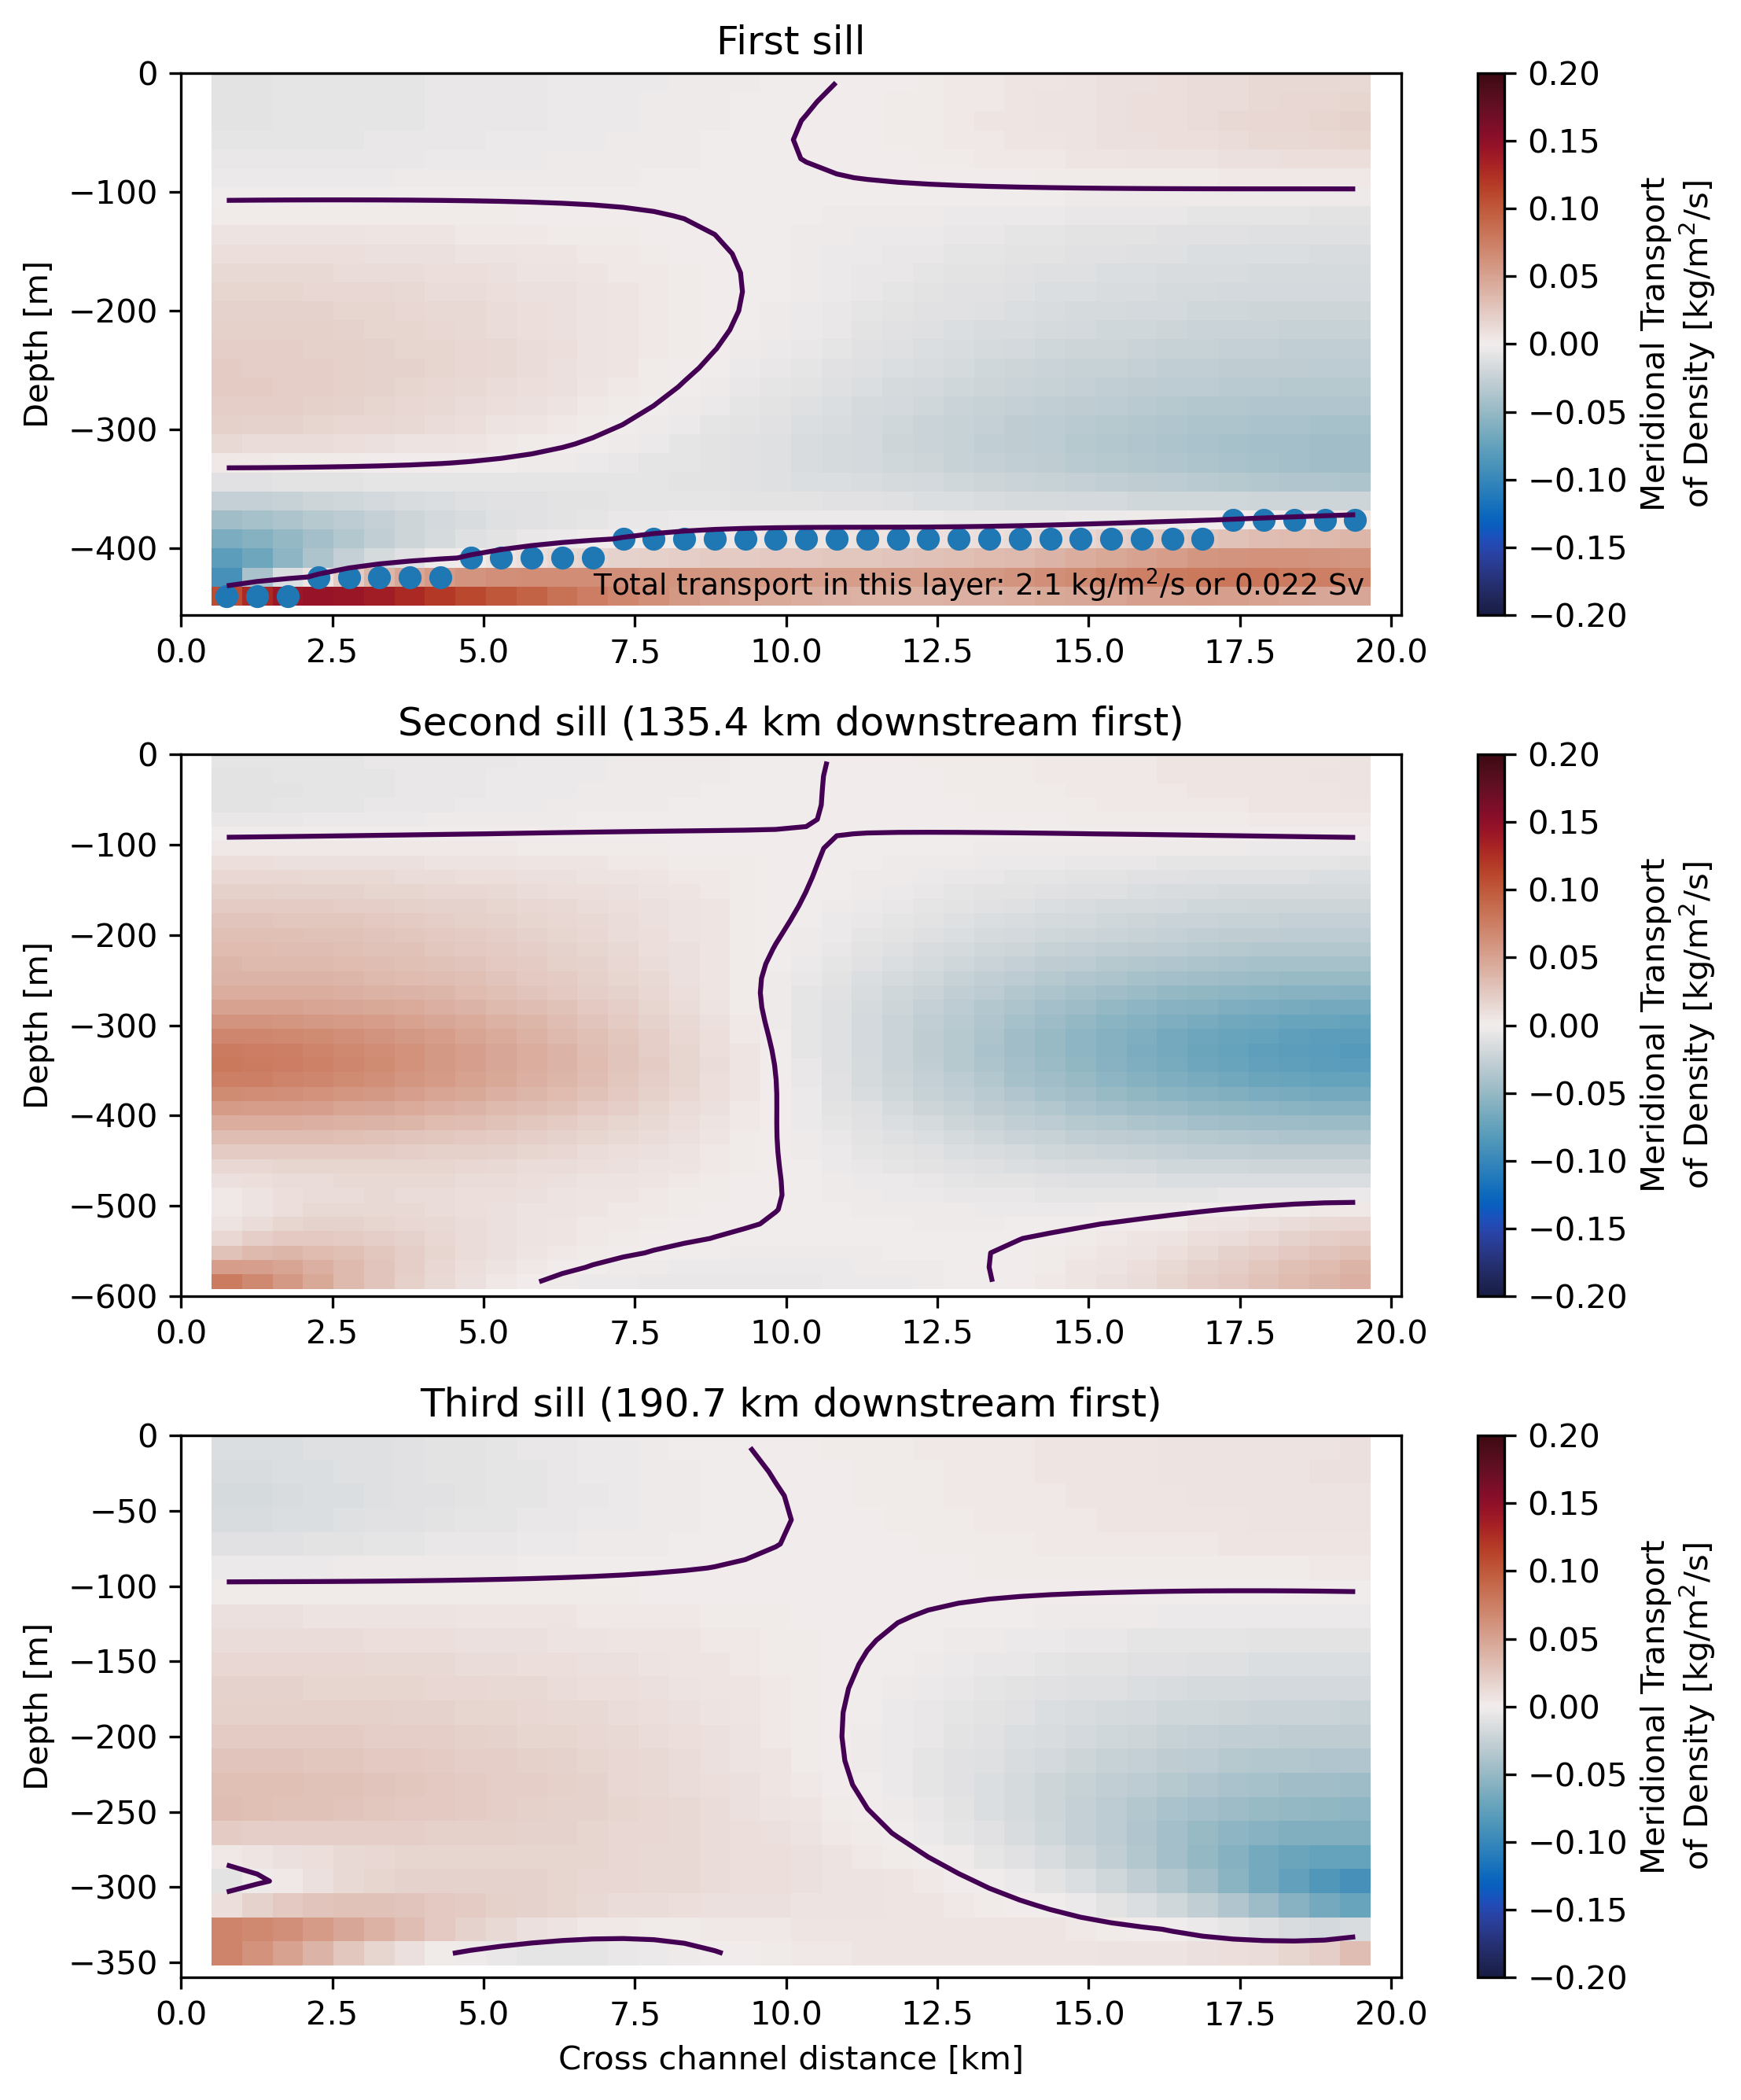

In [105]:
indy=np.arange(umbral1,umbralEnd1,1)
p=0 #np.arange(0,50,10)[0]
start=-5
fig,axin=plt.subplots(3)
ax=axin[0]
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[start:,:,umbral1,:],axis=0),mask=masks[:,umbral1,:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral1,5]==True][0]
ax.set_ylim((ymax,0))
ax.scatter(dsG.X[1:-1]/1000,depth[p])
cbar=plt.colorbar(cax)
cbar.set_label('Meridional Transport\nof Density [kg/m$^2$/s]')

ax.set(ylabel='Depth [m]',title='First sill')

ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[start:,:,umbral1,:],axis=0),mask=masks[:,umbral1,:]),levels=[0])

ax.text(dsG.X[13]/1000, dsG.Z[27], f'Total transport in this layer: {np.sum(MeridRhoTransp1[0]):.2g} kg/m$^2$/s or {np.sum(transp[0]):.2g} Sv', color='k',fontsize=9)

ax=axin[1]
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[start:,:,umbral2,:],axis=0),mask=masks[:,umbral2,:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral2,5]==True][0]
ax.set_ylim((ymax,0))
#ax.scatter(dsG.X[1:-1]/1000,depth[p])
cbar=plt.colorbar(cax)
cbar.set_label('Meridional Transport\nof Density [kg/m$^2$/s]')
ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[start:,:,umbral2,:],axis=0),mask=masks[:,umbral2,:]),levels=[0])
ax.set(ylabel='Depth [m]',title=f'Second sill ({(dsG.Yp1[umbral2].values - dsG.Yp1[umbral1].values)/1000:.1f} km downstream first)')
#ax.text(dsG.X[10]/1000, dsG.Z[26], f'Total transport in this layer {np.sum(MeridRhoTransp2[0]):.2g} kg/m$^2$/s ', color='k',fontsize=8)

ax=axin[2]
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[start:,:,umbral3,:],axis=0),mask=masks[:,umbral3,:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral3,5]==True][0]
ax.set_ylim((ymax,0))
#ax.scatter(dsG.X[1:-1]/1000,depth[p])
cbar=plt.colorbar(cax)
cbar.set_label('Meridional Transport\nof Density [kg/m$^2$/s]')
ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[start:,:,umbral3,:],axis=0),mask=masks[:,umbral3,:]),levels=[0])
ax.set(ylabel='Depth [m]',xlabel='Cross channel distance [km]',title=f'Third sill ({(dsG.Yp1[umbral3].values - dsG.Yp1[umbral1].values)/1000:.1f} km downstream first)')
#ax.text(dsG.X[10]/1000, dsG.Z[26], f'Total transport in this layer {np.sum(MeridRhoTransp3[0]):.2g} kg/m$^2$/s ', color='k',fontsize=8)

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeridTransport.png', bbox_inches='tight')

In [36]:
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=999.8*(1-np.ma.masked_array(ds.THETA[i].values-14,mask=mask)*alpha)

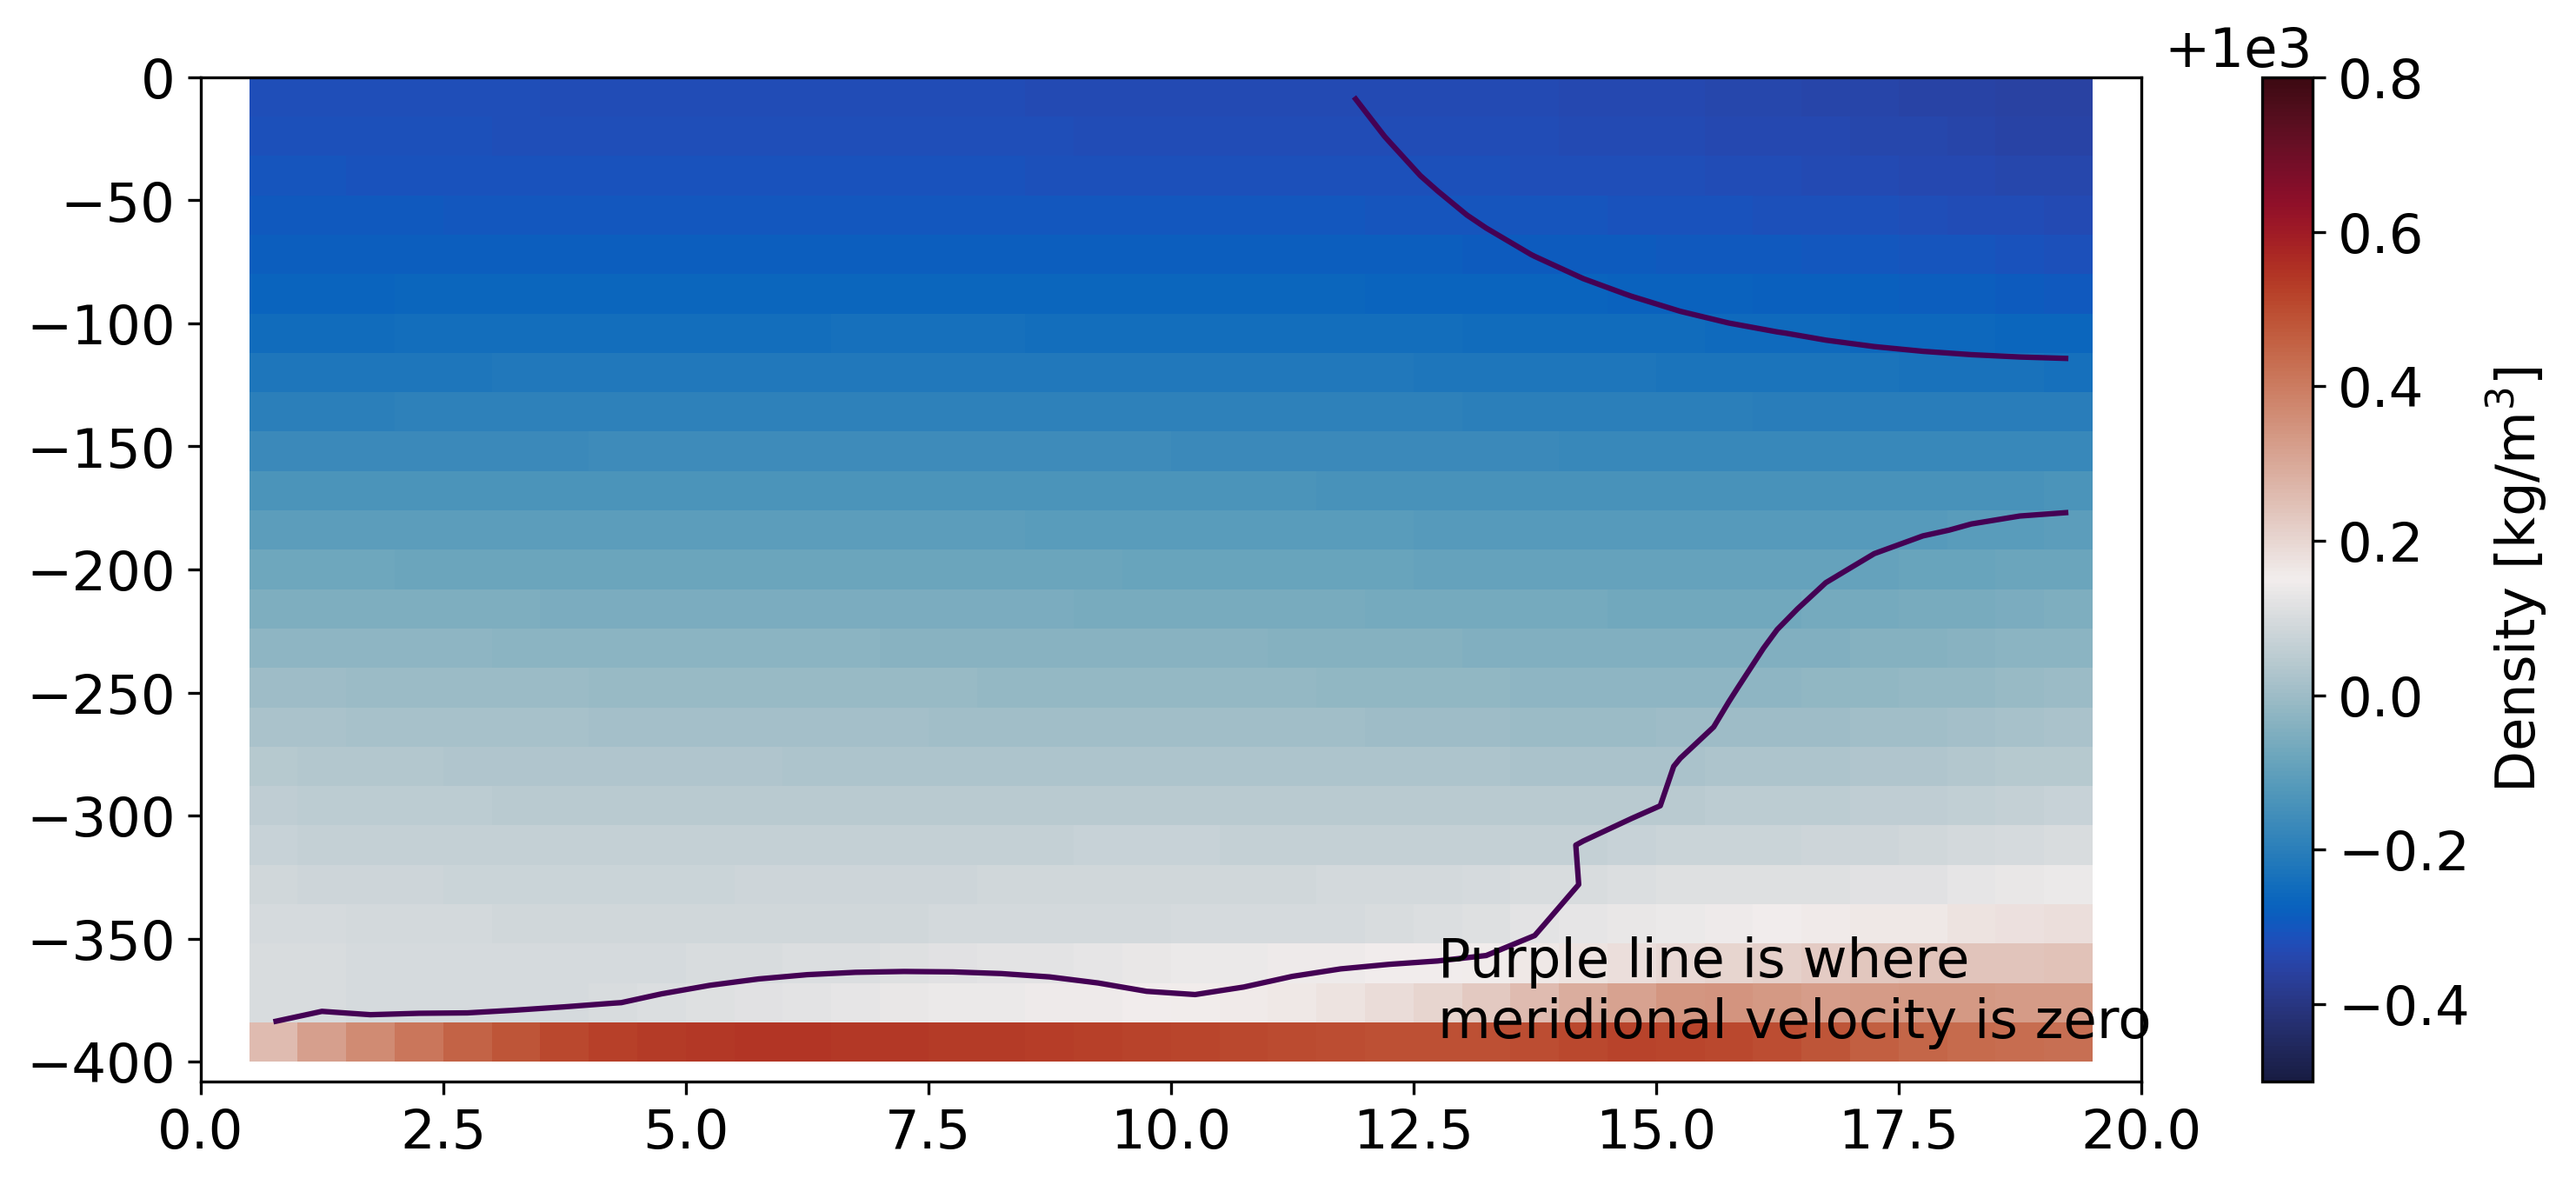

In [37]:
vmin=np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))
vmax=-np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))

plt.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),vmin=999.5,vmax=1000.8,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,umbral,5]==True][0]
plt.ylim((ymax,0))

cbar=plt.colorbar()
cbar.set_label('Density [kg/m$^{3}$]')
#plt.contour(dsG.X,dsG.Z[:35],ds.VVEL[-1,:35,umbral,:],levels=[0])
plt.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),levels=[0])
plt.text(dsG.X[25]/1000, -390, f'Purple line is where\nmeridional velocity is zero', color='k',fontsize=15)
#plt.scatter(dsG.X[1:-1],dsG.Z[siz])
#for i in range(len(siz)):
#    plt.text(dsG.X[1+i]-1000, dsG.Z[siz[i]]+40, f' {((dsG.Z[siz[i]]-ymax)*2000*vel[i]*1e-6):.1g} SV', color='k',fontsize=8)

#plt.text(dsG.X[5]-2000, -200, f'Total transport\n{np.sum((dsG.Z[siz]-ymax)*2000*vel*1e-6):.1g} SV', color='k',fontsize=8)

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'RhoTransport.png', bbox_inches='tight')

In [99]:
depindUmb=np.where(mask[:,umbral2,5])[0][0]-1

depind800=np.where(dsG.Z<-800)[0][0]

In [152]:
umbralStart2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][0]+int(ny/2)


umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [94]:
def BottomConc(vel, hfac, nz,nt, ny,nx,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny,nx))
    BottomInd = np.argmax(hfac[::-1,:,5]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            for k in range(nx): 
                BotVel[j,i,k] = vel[j,int(BottomInd[i]),i,k] 
                
    
    return (BotVel,BottomInd.astype(int))


In [95]:
nz=len(dsG.Z)
ny=len(dsG.Y)
nt=len(ds.T)
nx=len(dsG.X)

tempOut,BottomInd=BottomConc(ds.WRHOMASS[:,:,:,:],hFacC[:,:,:].values , nz, nt, ny,nx,1)
vvelOut,BottomInd=BottomConc(ds.VVEL[:,:,:,:],hFacS[:,:,:].values , nz, nt, ny+1,nx,1)
uvelOut,BottomInd=BottomConc(ds.UVEL[:,:,:,:],hFacW[:,:,:].values , nz, nt, ny,nx+1,1)

In [96]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

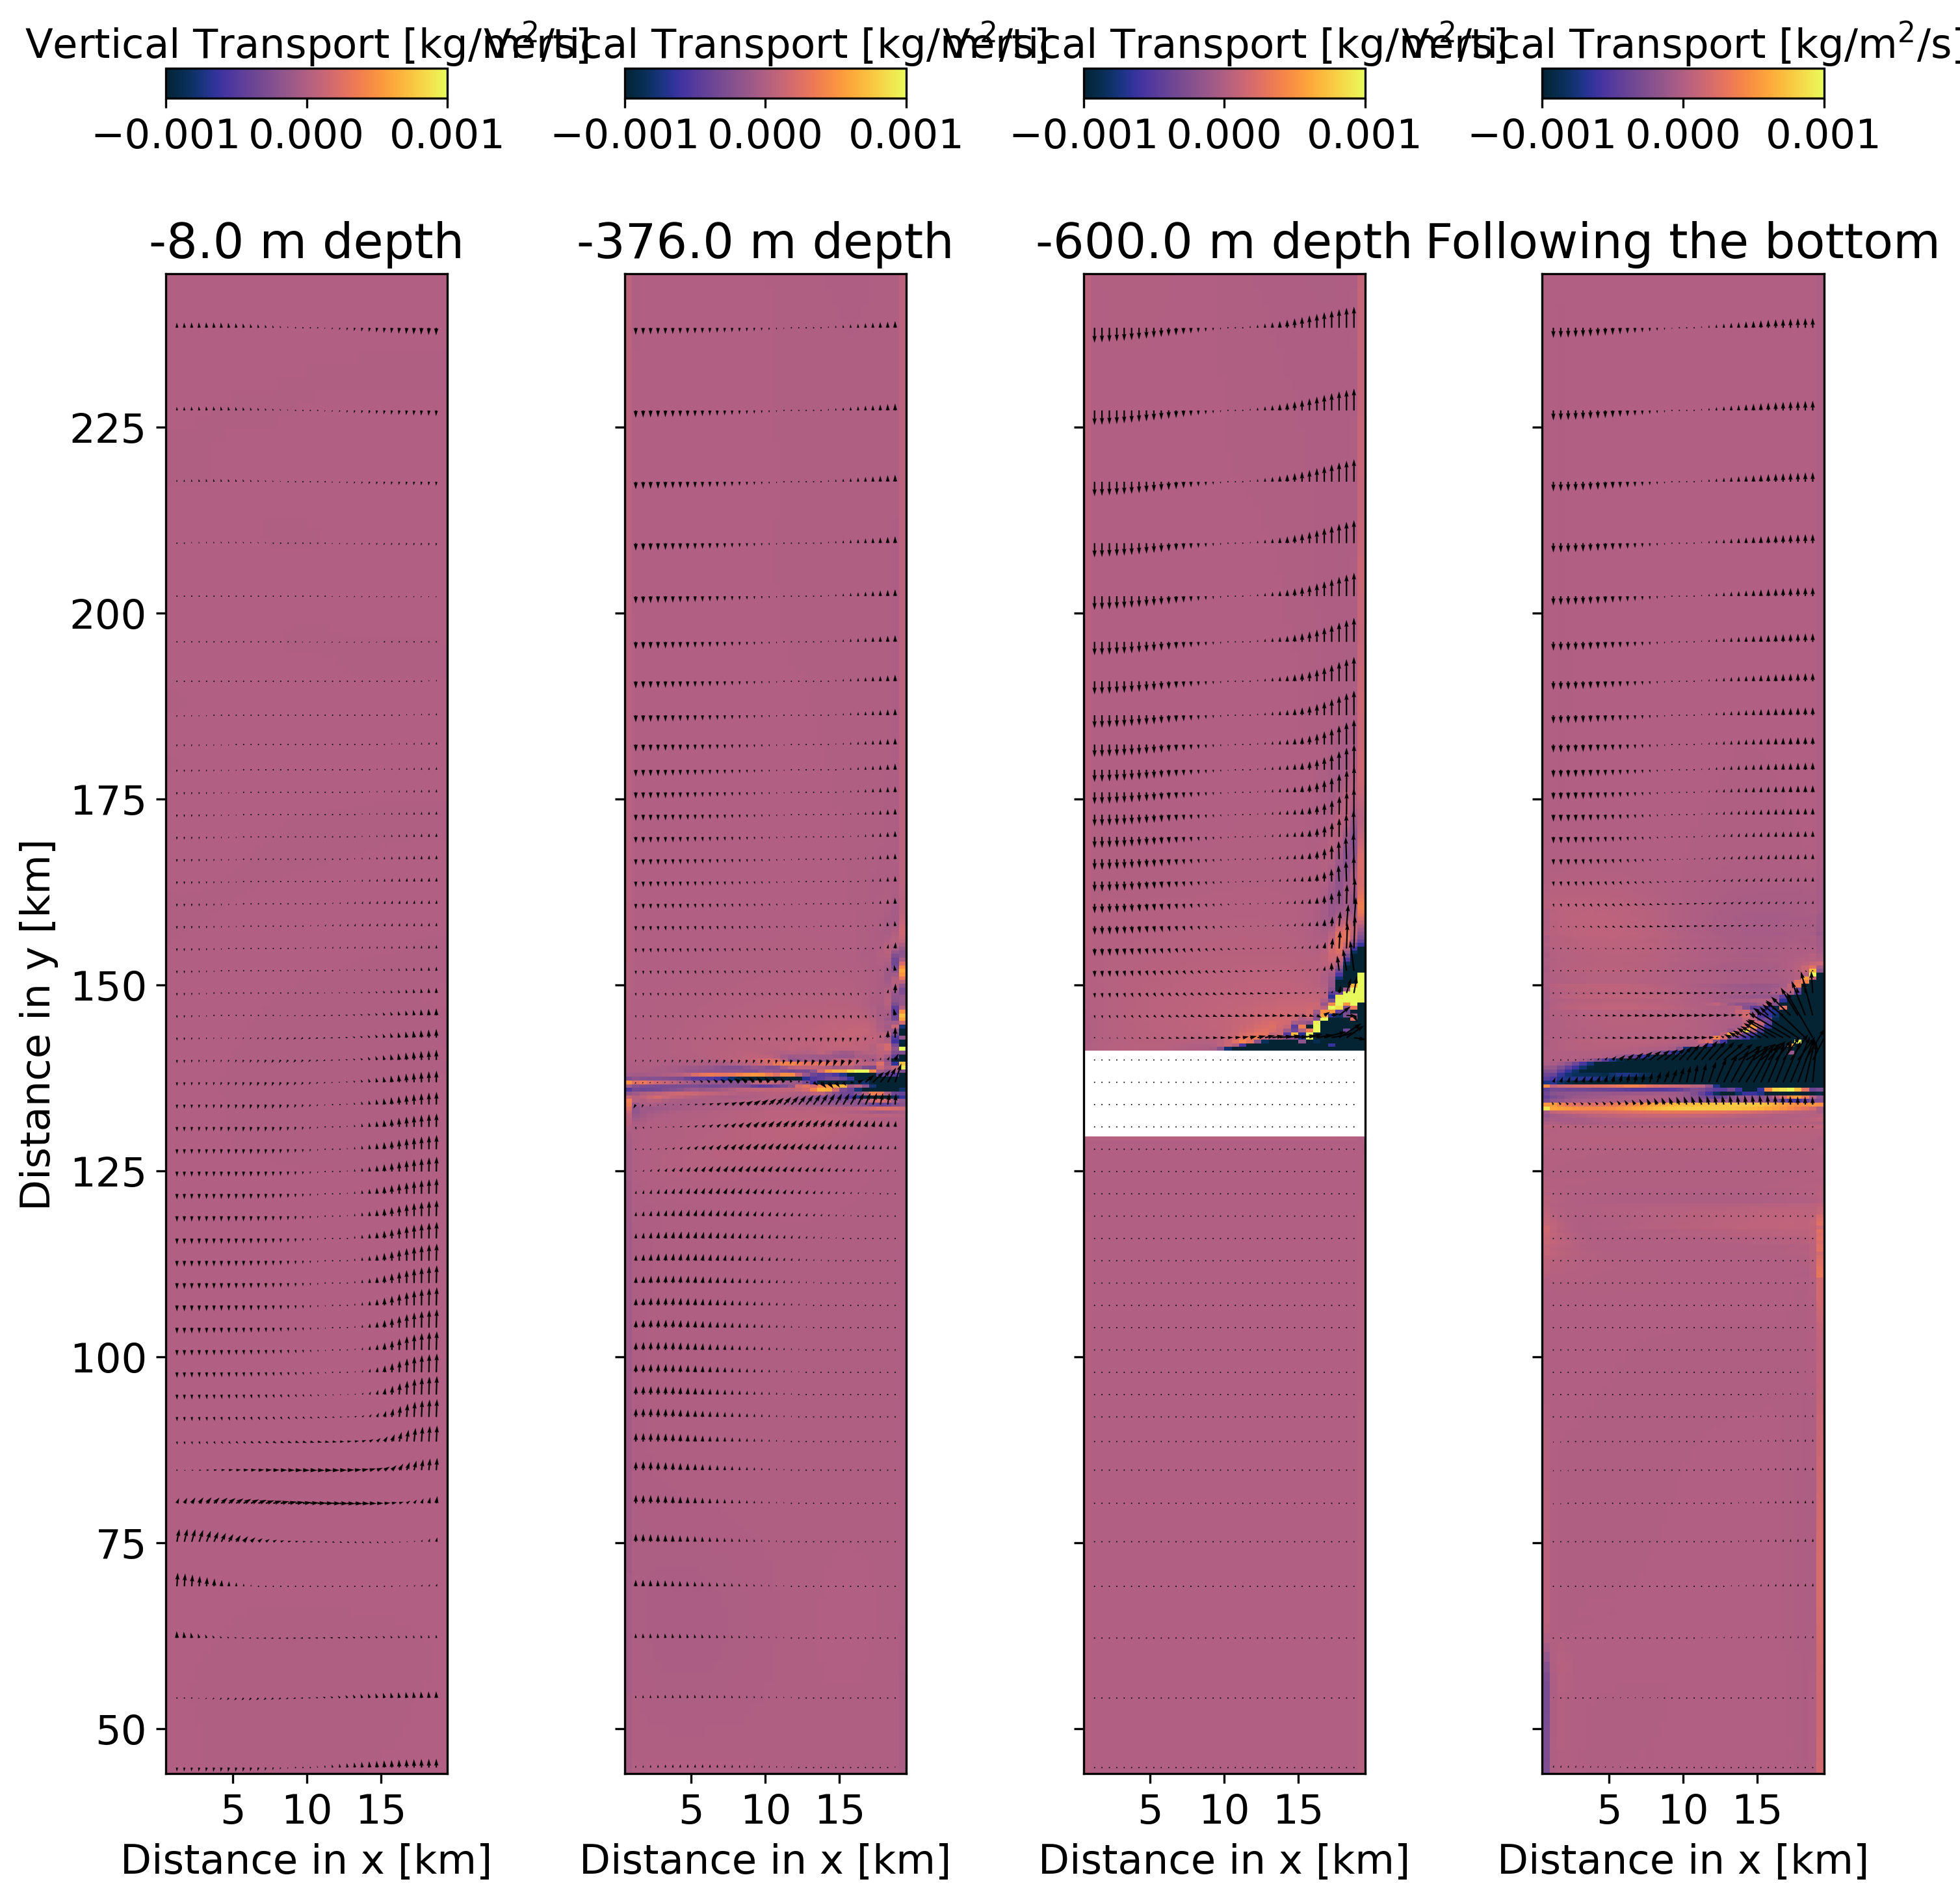

In [97]:
t=0
space=6
spacex=1
dep=[0,23,37]
VARS=list(ds.keys())[:]
widths = 0.005# np.linspace(0, 2, dsG.X[OBx:OBendx].values.size)

#for variable in VARS:

variable=VARS[2]

varin=ds.WRHOMASS
title= 'Vertical Transport [kg/m$^2$/s]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,ax=plt.subplots(1,4)


tin=-1


axin=ax[0]
vmin=-0.001 #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=0.001 #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[0],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[0],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[0]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[1]

#vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
#vmax=13 #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[1],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[1],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[1]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[2]

#vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
#vmax=12 # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[2],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[2],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[2]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[3]

#vmin= 10#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
#vmax= 12#np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')

indmean=23
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.mean(tempOut[start:end,OB:OBend,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(vvelOut[start:end,OB:OBend,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(uvelOut[start:end,OB:OBend,:],axis=0))
U=interpU((gridY,gridX))
gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:],width=widths)

axin.set(title=f'Following the bottom')


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'WtranspDifDepths.png', bbox_inches='tight')